In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
RANDOM_STATE = 42

In [3]:
# 1) Load dataset
data = fetch_openml(name="credit-g", version=1, as_frame=True)
df = data.frame.copy()

In [4]:
target_col = "class"
X_df = df.drop(columns=[target_col])
y = df[target_col]

In [6]:
numeric_features = X_df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_df.select_dtypes(exclude=["int64", "float64"]).columns.tolist()
print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

Numeric features (7): ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']
Categorical features (13): ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']


In [7]:
# 3) Preprocess
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=0.02, sparse_output=False), categorical_features),
    ],
    remainder="drop"
)

In [8]:
pipe = Pipeline([
    ("preprocess", preprocess),
    ("pca", PCA(n_components=0.8, random_state=RANDOM_STATE))
])

In [9]:
X_reduced = pipe.fit_transform(X_df)
print("Original transformed dim (after OHE):", preprocess.fit_transform(X_df).shape[1])
print("Reduced dim (after PCA 0.8):", X_reduced.shape[1])

Original transformed dim (after OHE): 59
Reduced dim (after PCA 0.8): 18


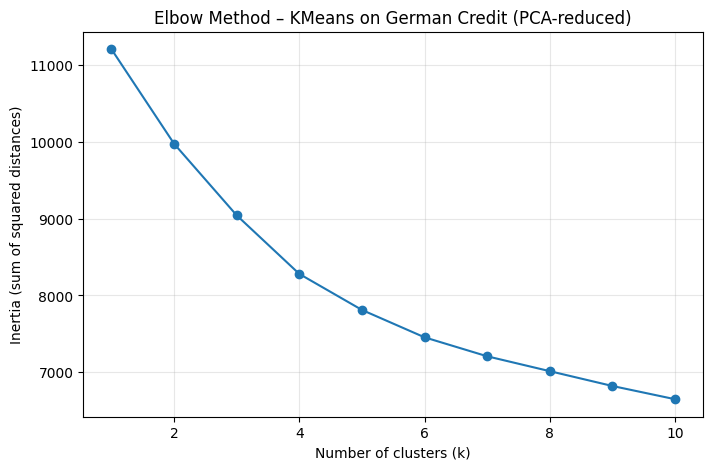

In [10]:
#Elbow method
k_values = list(range(1, 11))
inertias = []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_reduced)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o')
plt.title("Elbow Method – KMeans on German Credit (PCA-reduced)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (sum of squared distances)")
plt.grid(True, alpha=0.3)
plt.show()

In [30]:
k_opt = 5

In [31]:
km_final = KMeans(n_clusters=k_opt, random_state=RANDOM_STATE, n_init=10)
km_labels = km_final.fit_predict(X_reduced)

Explained variance ratio (vis PC1, PC2): [0.163 0.143]


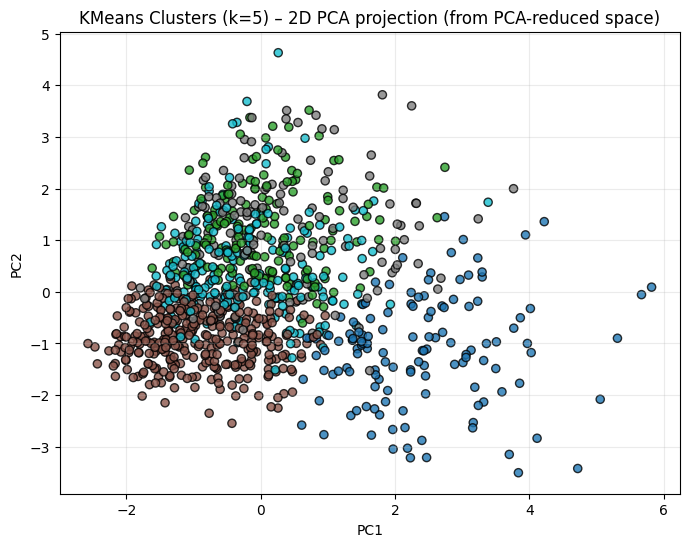

In [32]:
# 2D visualization
# PCA to 2D from X_reduced for plotting
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_vis2 = pca2.fit_transform(X_reduced)
print("Explained variance ratio (vis PC1, PC2):", np.round(pca2.explained_variance_ratio_, 3))

plt.figure(figsize=(8, 6))
plt.scatter(X_vis2[:, 0], X_vis2[:, 1], c=km_labels, cmap="tab10", s=35, edgecolor="k", alpha=0.8)
plt.title(f"KMeans Clusters (k={k_opt}) – 2D PCA projection (from PCA-reduced space)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.25)
plt.show()

In [33]:
# 3D visualization
# PCA to 3D from X_reduced for plotting

pca3 = PCA(n_components=3, random_state=RANDOM_STATE)
X_vis3 = pca3.fit_transform(X_reduced)
print("Explained variance ratio (vis PC1, PC2, PC3):", np.round(pca3.explained_variance_ratio_, 3))

df_plot = pd.DataFrame({
    "PC1": X_vis3[:, 0],
    "PC2": X_vis3[:, 1],
    "PC3": X_vis3[:, 2],
    "cluster": km_labels.astype(str)
})

fig = px.scatter_3d(
    df_plot, x="PC1", y="PC2", z="PC3",
    color="cluster",
    opacity=0.8,
    title=f"KMeans Clusters (k={k_opt}) – 3D PCA projection (from PCA-reduced space)"
)
fig.show()

Explained variance ratio (vis PC1, PC2, PC3): [0.163 0.143 0.103]


In [34]:
sil_km = silhouette_score(X_reduced, km_labels)
print(f"\nSilhouette score (KMeans, k={k_opt}) on PCA-reduced data: {sil_km:.3f}")


Silhouette score (KMeans, k=5) on PCA-reduced data: 0.117
